# Marsh Latin America — FP&A Regional Report
**Deliverable 2: Latin America Transactions & Restricted-Country Watchlist**

Covers:
- LATAM executive KPIs
- Full transaction listing filtered to Latin American countries
- Clients flagged for transactions with Russia, Cuba, China or Venezuela in Q4

In [7]:
import sys
import os
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib import rcParams
from IPython.display import display
sys.path.insert(0, 'src')
from engine import load_all_transactions, load_fx_rates
warnings.filterwarnings('ignore')

DATA_ROOT  = 'data'
FX_PATH    = os.path.join('data', '2023 Budget FX Rates.xlsx')
OUTPUT_DIR = 'output'
os.makedirs(OUTPUT_DIR, exist_ok=True)

MARSH_NAVY  = '#1C3F6E'
MARSH_BLUE  = '#2E75B6'
MARSH_LIGHT = '#BDD7EE'

rcParams.update({
    'figure.facecolor':  'white',
    'axes.facecolor':    '#F5F8FA',
    'axes.edgecolor':    '#CCCCCC',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.family':       'DejaVu Sans',
    'axes.titlesize':    13,
    'axes.titleweight':  'bold',
    'figure.dpi':        120,
})
pd.options.display.float_format = '{:,.2f}'.format

# ── Load & enrich ─────────────────────────────────────────────────────────────
print('Loading transactions...')
df_raw   = load_all_transactions(DATA_ROOT)
fx_rates = load_fx_rates(FX_PATH)

df = df_raw.copy()
df['Transaction']     = pd.to_numeric(df['Transaction'], errors='coerce')
df['Exchange_Rate']   = df['Currency'].map(fx_rates)
df['Transaction_USD'] = df['Transaction'] * df['Exchange_Rate']
df['Market_Section']  = df['Client'].str[0].str.upper()
df['Month']           = df['log_date'].dt.to_period('M')
df['Quarter']         = df['log_date'].dt.to_period('Q')
df['Country_upper']   = df['Country'].str.strip().str.upper()

# ── Latin America country list ────────────────────────────────────────────────
LATAM_COUNTRIES = {
    'ARGENTINA', 'BOLIVIA', 'BRAZIL', 'CHILE', 'COLOMBIA', 'COSTA RICA',
    'CUBA', 'DOMINICAN REPUBLIC', 'ECUADOR', 'EL SALVADOR', 'GUATEMALA',
    'HAITI', 'HONDURAS', 'JAMAICA', 'MEXICO', 'NICARAGUA', 'PANAMA',
    'PARAGUAY', 'PERU', 'PUERTO RICO', 'TRINIDAD AND TOBAGO', 'URUGUAY',
    'VENEZUELA', 'BELIZE', 'GUYANA', 'SURINAME', 'FRENCH GUIANA',
}

df_latam = df[df['Country_upper'].isin(LATAM_COUNTRIES)].copy()

print(f'  Total rows          : {len(df):>10,}')
print(f'  LATAM rows          : {len(df_latam):>10,}')
print(f'  LATAM share         : {len(df_latam)/len(df)*100:>9.1f}%')
print(f'  LATAM countries     : {df_latam["Country"].nunique():>10,}')
print(f'  LATAM unique clients: {df_latam["Client"].nunique():>10,}')

Loading transactions...
  Total rows          :    314,754
  LATAM rows          :     54,976
  LATAM share         :      17.5%
  LATAM countries     :         23
  LATAM unique clients:     20,962


## 1. Latin America — Executive KPIs

════════════════════════════════════════════════════
  MARSH LATIN AMERICA — FP&A REGIONAL SUMMARY
════════════════════════════════════════════════════
  Total Revenue (USD)   : $    371,278,631.34
  Global Revenue Share  :              17.5%
  Total Transactions    :             54,976
  Unique Clients        :             20,962
  Countries Represented :                 23
════════════════════════════════════════════════════

Top 10 LATAM Countries by Revenue:


,Country,Transaction_Count,Total_USD
0,PERU,"4,620","$30,886,953.62"
1,HAITI,"2,322","$16,570,902.71"
2,BOLIVIA,"2,342","$16,475,022.22"
3,PARAGUAY,"2,354","$16,295,055.74"
4,JAMAICA,"2,332","$16,251,633.62"
5,GUATEMALA,"2,279","$16,078,831.52"
6,SURINAME,"2,267","$15,935,583.52"
7,NICARAGUA,"2,321","$15,793,357.22"
8,PANAMA,"2,286","$15,675,635.94"
9,URUGUAY,"2,260","$15,601,527.69"


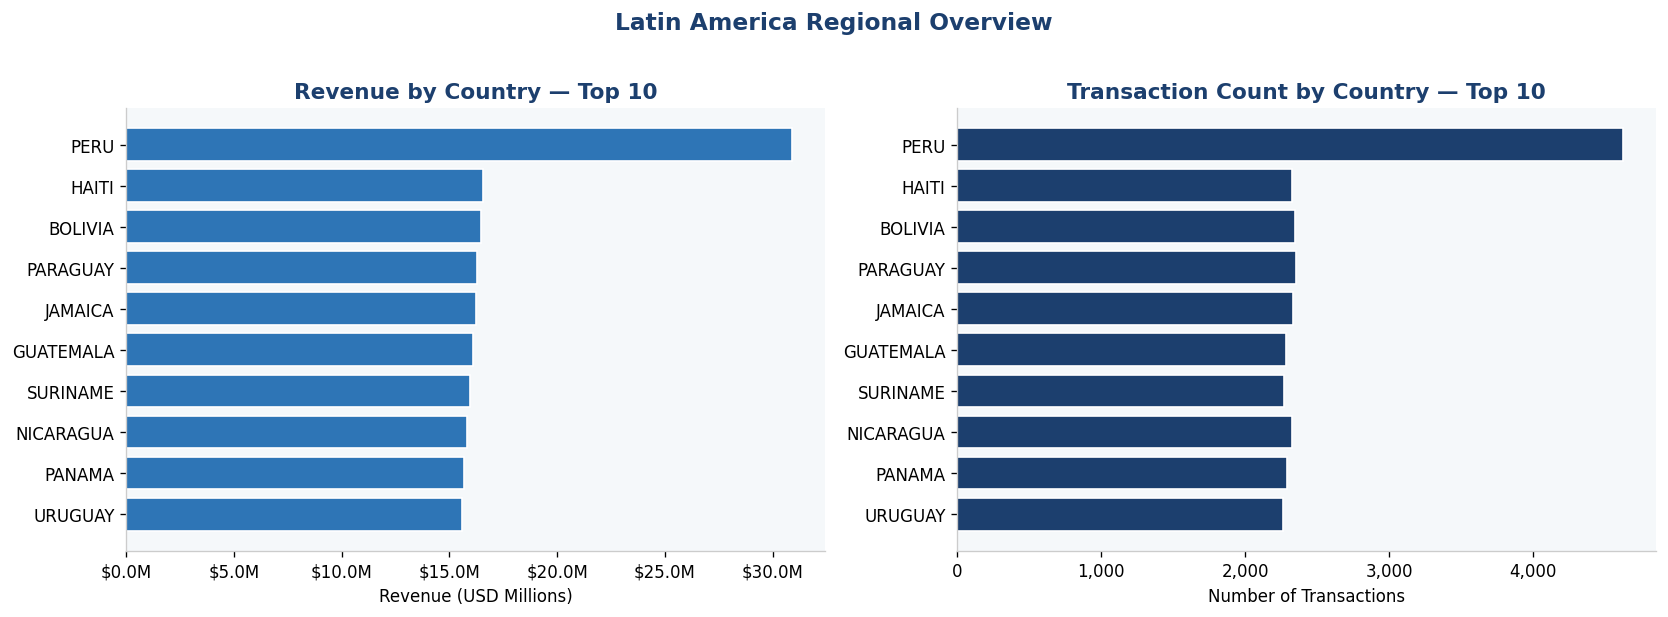

In [8]:
latam_rev       = df_latam['Transaction_USD'].sum()
latam_txn       = len(df_latam)
latam_clients   = df_latam['Client'].nunique()
latam_countries = df_latam['Country'].nunique()
latam_share_rev = latam_rev / df['Transaction_USD'].sum() * 100

print('═' * 52)
print('  MARSH LATIN AMERICA — FP&A REGIONAL SUMMARY')
print('═' * 52)
print(f'  Total Revenue (USD)   : ${latam_rev:>18,.2f}')
print(f'  Global Revenue Share  : {latam_share_rev:>17.1f}%')
print(f'  Total Transactions    : {latam_txn:>18,}')
print(f'  Unique Clients        : {latam_clients:>18,}')
print(f'  Countries Represented : {latam_countries:>18,}')
print('═' * 52)

# ── Revenue by LATAM country ──────────────────────────────────────────────────
latam_geo = (
    df_latam.groupby('Country')
    .agg(Transaction_Count=('Transaction', 'count'),
         Total_USD=('Transaction_USD', 'sum'))
    .reset_index()
    .sort_values('Total_USD', ascending=False)
    .reset_index(drop=True)
)

print(f'\nTop 10 LATAM Countries by Revenue:')
display(
    latam_geo.head(10).style
    .format({'Total_USD': '${:,.2f}', 'Transaction_Count': '{:,}'})
    .background_gradient(subset='Total_USD', cmap='Blues')
    .set_caption('Top 10 LATAM Countries by Revenue (USD)')
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar: revenue by country
top10 = latam_geo.head(10)
axes[0].barh(top10['Country'][::-1], top10['Total_USD'][::-1] / 1e6,
             color=MARSH_BLUE, edgecolor='white')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:.1f}M'))
axes[0].set_title('Revenue by Country — Top 10', color=MARSH_NAVY)
axes[0].set_xlabel('Revenue (USD Millions)')

# Bar: transactions by country
axes[1].barh(top10['Country'][::-1], top10['Transaction_Count'][::-1],
             color=MARSH_NAVY, edgecolor='white')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v):,}'))
axes[1].set_title('Transaction Count by Country — Top 10', color=MARSH_NAVY)
axes[1].set_xlabel('Number of Transactions')

plt.suptitle('Latin America Regional Overview', y=1.02,
             fontsize=14, fontweight='bold', color=MARSH_NAVY)
plt.tight_layout()
plt.show()

## 2. LATAM Transactions
All transactions originating from Latin American countries, with local amount and USD equivalent.

In [9]:
# Export-ready LATAM transaction table
latam_txns = (
    df_latam[['Client', 'Country', 'Currency', 'Transaction',
               'Exchange_Rate', 'Transaction_USD', 'log_date']]
    .copy()
    .sort_values(['Country', 'Client', 'log_date'])
    .reset_index(drop=True)
)
latam_txns['log_date'] = latam_txns['log_date'].dt.strftime('%Y-%m-%d')
latam_txns.columns = ['Client', 'Country', 'Currency', 'Amount (Local)',
                      'Exchange Rate', 'Amount (USD)', 'Date']

print(f'LATAM transactions: {len(latam_txns):,}')
display(
    latam_txns.head(20).style
    .format({'Amount (Local)': '{:,.2f}', 'Amount (USD)': '${:,.2f}',
             'Exchange Rate': '{:.6f}'})
    .set_caption('LATAM Transactions (first 20 rows shown)')
)

LATAM transactions: 54,976


,Client,Country,Currency,Amount (Local),Exchange Rate,Amount (USD),Date
0,11113,ARGENTINA,BND,375.91,0.723746,$272.06,2024-08-29
1,AAABM,ARGENTINA,IQD,"456,664.35",0.000685,$312.78,2024-10-25
2,AAACN,ARGENTINA,YER,"208,962.68",0.003998,$835.44,2024-09-06
3,AAACc,ARGENTINA,UAH,"152,092.34",0.027077,"$4,118.15",2024-12-18
4,AAAE1,ARGENTINA,LKR,"26,814,148.93",0.002721,"$72,957.81",2024-06-27
5,AAAHX,ARGENTINA,SVC,"1,893.68",0.114286,$216.42,2024-02-19
6,AAAVX,ARGENTINA,YER,"399,575.43",0.003998,"$1,597.51",2024-04-10
7,AABGY,ARGENTINA,IRR,"103,291,300.23",0.000024,"$2,459.37",2024-02-17
8,AABHN,ARGENTINA,PYG,"41,821,727.07",0.000139,"$5,816.57",2024-10-23
9,AABKN,ARGENTINA,IRR,"89,684,489.32",0.000024,"$2,135.39",2024-09-26


## 3. Restricted-Country Watchlist — Q4
Clients that had **any** transaction with **Russia, Cuba, China or Venezuela** during the last quarter of the data period (Q4 2024: Oct–Dec).

In [ ]:
RESTRICTED = {'RUSSIA', 'RUSIA', 'CUBA', 'CHINA', 'VENEZUELA'}

# Last quarter of the data (Q4 — Oct through Dec of the data year)
data_year   = df['log_date'].dt.year.mode()[0]
q4_start    = pd.Timestamp(f'{data_year}-10-01')
q4_end      = pd.Timestamp(f'{data_year}-12-31')

df_q4 = df[(df['log_date'] >= q4_start) & (df['log_date'] <= q4_end)].copy()
df_restricted = df_q4[df_q4['Country_upper'].isin(RESTRICTED)].copy()

print(f'Reference period  : {q4_start.date()} → {q4_end.date()}')
print(f'Q4 total rows     : {len(df_q4):,}')
print(f'Restricted rows   : {len(df_restricted):,}')
print(f'Flagged clients   : {df_restricted["Client"].nunique():,}')

# ── Summary per client ────────────────────────────────────────────────────────
watchlist = (
    df_restricted
    .groupby('Client')
    .agg(
        Restricted_Countries=('Country', lambda x: ', '.join(sorted(x.str.title().unique()))),
        Transaction_Count=('Transaction', 'count'),
        Total_USD=('Transaction_USD', 'sum'),
    )
    .reset_index()
    .sort_values('Total_USD', ascending=False)
    .reset_index(drop=True)
)
watchlist.insert(0, 'Flag', '⚠')
watchlist.columns = ['Flag', 'Client', 'Restricted Countries',
                     'Transaction Count', 'Total Amount (USD)']

print(f'\nFlagged Client List ({len(watchlist)} clients):')
display(
    watchlist.style
    .format({'Total Amount (USD)': '${:,.2f}', 'Transaction Count': '{:,}'})
    .set_properties(subset=['Flag'], **{'color': '#B71C1C', 'font-weight': 'bold'})
    .background_gradient(subset='Total Amount (USD)', cmap='Reds')
    .set_caption(f'Clients with Restricted-Country Transactions — Q4 {data_year}')
)

# ── Breakdown by restricted country ──────────────────────────────────────────
by_country = (
    df_restricted.groupby('Country_upper')
    .agg(Clients=('Client', 'nunique'),
         Transactions=('Transaction', 'count'),
         Total_USD=('Transaction_USD', 'sum'))
    .reset_index()
    .rename(columns={'Country_upper': 'Country'})
    .sort_values('Total_USD', ascending=False)
)

print('\nBreakdown by restricted country:')
# display the head (20 rows) of the results:
display(
    by_country.style
    .format({'Total_USD': '${:,.2f}', 'Transactions': '{:,}', 'Clients': '{:,}'})
    .set_caption('Restricted Country Breakdown — Q4')
)

Reference period  : 2024-10-01 → 2024-12-31
Q4 total rows     : 102,206
Restricted rows   : 1,501
Flagged clients   : 1,355

Flagged Client List (1355 clients):


,Flag,Client,Restricted Countries,Transaction Count,Total Amount (USD)
0,⚠,DFK23,China,1,"$141,124.46"
1,⚠,AGGWc,China,1,"$130,709.16"
2,⚠,BEHV1,Venezuela,1,"$121,728.81"
3,⚠,AFLX2,Venezuela,2,"$105,383.48"
4,⚠,ELWbc,Venezuela,2,"$82,856.33"
5,⚠,CCXX1,China,1,"$76,659.98"
6,⚠,ELMYc,China,1,"$73,966.07"
7,⚠,LWWab,"China, Venezuela",2,"$73,347.69"
8,⚠,FLNYZ,China,1,"$73,250.26"
9,⚠,BELMZ,China,1,"$65,986.83"



Breakdown by restricted country:


,Country,Clients,Transactions,Total_USD
0,CHINA,740,771,"$5,531,656.24"
1,VENEZUELA,687,730,"$4,354,830.32"


## 4. Export — Deliverable 2 Excel Report

Generates `output/Deliverable_2_LatinAmerica.xlsx` with 3 sheets:

| Sheet | Contents |
|---|---|
| LATAM Summary | KPI cards + revenue by country chart |
| LATAM Transactions | All transactions from Latin American countries |
| Restricted Watchlist | Clients flagged for Q4 restricted-country transactions |

In [12]:
import importlib, engine as _eng
importlib.reload(_eng)

import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.chart import BarChart, Reference
from openpyxl.utils import get_column_letter
from openpyxl.cell.cell import MergedCell
from engine import _fill, _font, _border, _write_table, _write_fast

# Inline fix: skip MergedCell objects; derive column letter from index
def _aw(ws, lo=8, hi=45):
    for i, col in enumerate(ws.columns, start=1):
        w = max(
            (len(str(c.value or '')) for c in col if not isinstance(c, MergedCell)),
            default=lo,
        )
        ws.column_dimensions[get_column_letter(i)].width = min(max(w + 2, lo), hi)

XL_NAVY  = '1C3F6E'
XL_BLUE  = '2E75B6'
XL_LIGHT = 'BDD7EE'
XL_WHITE = 'FFFFFF'
XL_RED   = 'B71C1C'
XL_LRED  = 'FFEBEE'

wb = openpyxl.Workbook()

# ═══════════════════════════════════════════════════════════════════════════════
# Sheet 1: LATAM Summary
# ═══════════════════════════════════════════════════════════════════════════════
ws1 = wb.active
ws1.title = 'LATAM Summary'
ws1.sheet_view.showGridLines = False

for rh, val, sz, bold in [
    (1, '', 8, False),
    (2, f'MARSH  |  Latin America FP&A Report — {data_year}', 20, True),
    (3, 'Deliverable 2: Regional Transactions & Restricted-Country Watchlist', 11, False),
    (4, '', 8, False),
]:
    ws1.merge_cells(f'A{rh}:J{rh}')
    cell = ws1.cell(row=rh, column=1, value=val)
    cell.fill = _fill(XL_NAVY)
    cell.font = Font(name='Calibri', size=sz, bold=bold, color=XL_WHITE)
    cell.alignment = Alignment(horizontal='center', vertical='center')
    ws1.row_dimensions[rh].height = 8 if not val else (48 if sz > 15 else 22)

ws1.row_dimensions[6].height = 50
ws1.row_dimensions[7].height = 20
ws1.row_dimensions[8].height = 8

for value, label, c1, c2 in [
    (f'${latam_rev / 1e6:.1f} M', 'LATAM Revenue (USD)', 'B', 'C'),
    (f'{latam_txn:,}',             'Transactions',        'D', 'E'),
    (f'{latam_clients:,}',         'Unique Clients',      'F', 'G'),
    (f'{latam_countries:,}',       'Countries',           'H', 'I'),
]:
    ws1.merge_cells(f'{c1}6:{c2}6')
    ws1.merge_cells(f'{c1}7:{c2}7')
    v = ws1[f'{c1}6']
    v.value = value; v.fill = _fill(XL_BLUE)
    v.font = Font(name='Calibri', size=22, bold=True, color=XL_WHITE)
    v.alignment = Alignment(horizontal='center', vertical='center')
    l = ws1[f'{c1}7']
    l.value = label; l.fill = _fill(XL_LIGHT)
    l.font = Font(name='Calibri', size=10, bold=True, color=XL_NAVY)
    l.alignment = Alignment(horizontal='center', vertical='center')

ws1.merge_cells('A10:J10')
h = ws1['A10']
h.value = '  REVENUE BY COUNTRY'; h.fill = _fill(XL_NAVY)
h.font = _font(XL_WHITE, True, 11)
h.alignment = Alignment(horizontal='left', vertical='center')
ws1.row_dimensions[10].height = 22

geo_ws1 = latam_geo.copy()
geo_ws1.insert(0, 'Rank', range(1, len(geo_ws1) + 1))
geo_ws1.columns = ['Rank', 'Country', 'Transaction Count', 'Total Revenue (USD)']
_write_table(ws1, geo_ws1, sr=11)
for r in range(12, 12 + len(geo_ws1)):
    ws1.cell(r, 3).number_format = '#,##0'
    ws1.cell(r, 4).number_format = '"$"#,##0.00'
_aw(ws1)

ch = BarChart()
ch.type = 'bar'; ch.title = 'Revenue by LATAM Country (USD)'; ch.style = 10
ch.y_axis.title = 'Country'; ch.x_axis.title = 'Revenue (USD)'
ch.width = 22; ch.height = 16
tg = min(16, len(geo_ws1) + 1)
ch.add_data(Reference(ws1, min_col=4, min_row=11, max_row=11 + tg - 1), titles_from_data=True)
ch.set_categories(Reference(ws1, min_col=2, min_row=12, max_row=11 + tg - 1))
ws1.add_chart(ch, 'F11')

ws1.column_dimensions['A'].width = 6
ws1.column_dimensions['B'].width = 26

# ═══════════════════════════════════════════════════════════════════════════════
# Sheet 2: LATAM Transactions  (large — fast path)
# ═══════════════════════════════════════════════════════════════════════════════
ws2 = wb.create_sheet('LATAM Transactions')
ws2.sheet_view.showGridLines = False
ws2.freeze_panes = 'A2'
_write_fast(ws2, latam_txns, col_widths=[12, 22, 12, 18, 14, 18, 12])

# ═══════════════════════════════════════════════════════════════════════════════
# Sheet 3: Restricted Watchlist
# ═══════════════════════════════════════════════════════════════════════════════
ws3 = wb.create_sheet('Restricted Watchlist')
ws3.sheet_view.showGridLines = False
ws3.freeze_panes = 'A2'

ws3.merge_cells('A1:F1')
wb_cell = ws3['A1']
wb_cell.value = f'  ⚠  RESTRICTED-COUNTRY TRANSACTIONS — Q4 {data_year}  (Russia · Cuba · China · Venezuela)'
wb_cell.fill = _fill(XL_RED)
wb_cell.font = Font(name='Calibri', size=11, bold=True, color=XL_WHITE)
wb_cell.alignment = Alignment(horizontal='left', vertical='center')
ws3.row_dimensions[1].height = 24

wl = watchlist.copy()
b = _border()
ws3.row_dimensions[2].height = 22
for c, col in enumerate(wl.columns, start=1):
    cell = ws3.cell(row=2, column=c, value=col)
    cell.fill = _fill(XL_RED); cell.font = _font(XL_WHITE, True, 10)
    cell.border = b
    cell.alignment = Alignment(horizontal='center', vertical='center')

for r, row in enumerate(wl.itertuples(index=False), start=3):
    rf = _fill(XL_LRED) if (r % 2 == 0) else _fill(XL_WHITE)
    for c, val in enumerate(row, start=1):
        cell = ws3.cell(row=r, column=c, value=val)
        cell.fill = rf; cell.border = b
        if c == 1:
            cell.font = Font(name='Calibri', size=11, bold=True, color=XL_RED)
            cell.alignment = Alignment(horizontal='center', vertical='center')
        elif isinstance(val, float):
            cell.font = _font()
            cell.number_format = '"$"#,##0.00'
            cell.alignment = Alignment(horizontal='right', vertical='center')
        elif isinstance(val, int):
            cell.font = _font()
            cell.number_format = '#,##0'
            cell.alignment = Alignment(horizontal='right', vertical='center')
        else:
            cell.font = _font()
            cell.alignment = Alignment(horizontal='left', vertical='center')

_aw(ws3)
ws3.column_dimensions['A'].width = 6

# ── Save ──────────────────────────────────────────────────────────────────────
out = os.path.join(OUTPUT_DIR, 'Deliverable_2_LatinAmerica.xlsx')
wb.save(out)
print(f'Report saved → {out}')

Report saved → output\Deliverable_2_LatinAmerica.xlsx
